In [1]:
%load_ext autoreload
%autoreload 2

from noise import *
from pathlib import Path 
import json
from data import *
from trackers import *

import matplotlib.pyplot as plt
import numpy as np
import pywt
# from main import *

/mnt/home/nzilberstein/venvs/diffusion/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_exp(name, step="last", log=True, dataloaders=False):
    """ Load an experiment with a given name. step can be an integer, "best", or "last" (default). """
    exp_dir = Path("models") / name

    with open(exp_dir / "args.json") as f:
        args_dict = json.load(f)

    return args_dict

args = load_exp("multigpu/combined_cov_tworandvars/energy_song_anisoEmb_groupNorm_lambda1_mult_lr2e-4_nolrdecay_1000warmup_d2", step = "last")

## Testing covariance

In [4]:
# Load data from CIFAR10 using the libraries from torch

# Get the dataloaders from torchvision library
# import torchvision
# import torchvision.transforms as transforms
# from torch.utils.data import DataLoader

# transform = transforms.Compose([
#     transforms.ToTensor(),
# ])
# trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
# trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
# testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
# testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)  

# images = next(iter(trainloader))[0]

test_batch_size = 32
H = 32
CHW = 3 * H * H

train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=args["horizontal_flip"], data_subset=eval(args["data_subset"]),
    train_batch_size=test_batch_size, test_batch_size=test_batch_size, num_workers=args["num_workers"], seed=2
)

images = next(iter(test_dataloader))  # load for testing things.

In [9]:
from scipy.linalg import toeplitz

## downscale - super resolution ##
# blur_by = int(2)
img_dim = images[0][0].shape[-1]
# print(img_size)
# H = torch.zeros((img_dim // (blur_by**2), img_dim))
# H.shape
# for i in range(img_size  // blur_by):
#     for j in range(img_size // blur_by):
#         for i_inc in range(blur_by):
#             for j_inc in range(blur_by):
#                 H[i * img_size // blur_by + j, (blur_by*i + i_inc) * img_size + (blur_by*j + j_inc)] = (1/blur_by**2)

# Deblurring

def kernel_to_matrix(F, I_row_num, I_col_num):
    """
    Arg:
    F -- numpy 2D matrix - kernel of the blur
    I_row_num - number of rows in signal
    I_col_num - number of cols in signal
    
    Returns: 
    output -- 2D numpy matrix, which operates on a signal I of size 
    """

    # number of columns and rows of the filter
    F_row_num, F_col_num = F.shape

    #  calculate the output dimensions
    output_row_num = I_row_num + F_row_num - 1
    output_col_num = I_col_num + F_col_num - 1
    #if print_ir: print('output dimension:', output_row_num, output_col_num)

    # zero pad the filter
    F_zero_padded = np.pad(F, ((output_row_num - F_row_num, 0),
                               (0, output_col_num - F_col_num)),
                            'constant', constant_values=0)
    #if print_ir: print('F_zero_padded: ', F_zero_padded)

    # use each row of the zero-padded F to creat a toeplitz matrix. 
    #  Number of columns in this matrices are same as numbe of columns of input signal
    toeplitz_list = []
    for i in range(F_zero_padded.shape[0]-1, -1, -1): # iterate from last row to the first row
        c = F_zero_padded[i, :] # i th row of the F 
        r = np.r_[c[0], np.zeros(I_col_num-1)] # first row for the toeplitz fuction should be defined otherwise
                                                            # the result is wrong
        toeplitz_m = toeplitz(c,r) # this function is in scipy.linalg library
        toeplitz_list.append(toeplitz_m)
        #if print_ir: print('F '+ str(i)+'\n', toeplitz_m)

        # doubly blocked toeplitz indices: 
    #  this matrix defines which toeplitz matrix from toeplitz_list goes to which part of the doubly blocked
    c = range(1, F_zero_padded.shape[0]+1)
    r = np.r_[c[0], np.zeros(I_row_num-1, dtype=int)]
    doubly_indices = toeplitz(c, r)
    #if print_ir: print('doubly indices \n', doubly_indices)

    ## creat doubly blocked matrix with zero values
    toeplitz_shape = toeplitz_list[0].shape # shape of one toeplitz matrix
    h = toeplitz_shape[0]*doubly_indices.shape[0]
    w = toeplitz_shape[1]*doubly_indices.shape[1]
    doubly_blocked_shape = [h, w]
    doubly_blocked = np.zeros(doubly_blocked_shape)

    # tile toeplitz matrices for each row in the doubly blocked matrix
    b_h, b_w = toeplitz_shape # hight and withs of each block
    for i in range(doubly_indices.shape[0]):
        for j in range(doubly_indices.shape[1]):
            start_i = i * b_h
            start_j = j * b_w
            end_i = start_i + b_h
            end_j = start_j + b_w
            doubly_blocked[start_i: end_i, start_j:end_j] = toeplitz_list[doubly_indices[i,j]-1]

    return doubly_blocked

def get_custom_kernel(type = "gauss", dim = 64):
    kernel = 0
    if type == "14641":
        kernel = np.array([[1, 4, 6, 4, 1]])
        kernel = np.matmul(kernel.transpose(1, 0), kernel) / 256.0
    elif type == "uniform":
        kernel = np.array([[1, 1, 1, 1, 1]])
        kernel = np.matmul(kernel.transpose(1, 0), kernel) / 25.0
    elif type == "gauss":
        #sigma 10
        kernel = np.array([[0.03920520445985253,0.03979771524812676,0.0399972021259645,0.03979771524812676,0.03920520445985253],
                           [0.03979771524812676,0.04039918069022969,0.04060168242614218,0.04039918069022969,0.03979771524812676],
                           [0.0399972021259645,0.04060168242614218,0.04080519920622999,0.04060168242614218,0.0399972021259645],
                           [0.03979771524812676,0.04039918069022969,0.04060168242614218,0.04039918069022969,0.03979771524812676],
                           [0.03920520445985253,0.03979771524812676,0.0399972021259645,0.03979771524812676,0.03920520445985253]])
    H = kernel_to_matrix(kernel, dim, dim)
    H = H[[row*(dim+4)+col for row in range(2, dim+2) for col in range(2,dim+2)], :]
    return H, kernel


H, kernel = get_custom_kernel(type="gauss", dim = img_dim)
H = torch.from_numpy(H).type(torch.FloatTensor)

# HtH = torch.t(H) @ H
H_fourier = torch.fft.fft2(torch.linalg.inv(H), norm="ortho")
kernel = torch.tensor(kernel)
# H_4d = HtH.view(32,32,32,32)

NameError: name 'images' is not defined

In [5]:
import scipy 

class Blurkernel(torch.nn.Module):
    def __init__(self, blur_type='gaussian', kernel_size=5, std=3.0, device=None):
        super().__init__()
        self.blur_type = blur_type
        self.kernel_size = kernel_size
        self.std = std
        self.device = device
        self.seq = torch.nn.Sequential(
            torch.nn.ReflectionPad2d(self.kernel_size//2),
            torch.nn.Conv2d(3, 3, self.kernel_size, stride=1, padding=0, bias=False, groups=3)
        )

        self.weights_init()

    def forward(self, x):
        return self.seq(x)

    def weights_init(self):
        if self.blur_type == "gaussian":
            n = np.zeros((self.kernel_size, self.kernel_size))
            n[self.kernel_size // 2,self.kernel_size // 2] = 1
            k = scipy.ndimage.gaussian_filter(n, sigma=self.std)
            k = torch.from_numpy(k)
            self.k = k
            for name, f in self.named_parameters():
                f.data.copy_(k)

    def update_weights(self, k):
        if not torch.is_tensor(k):
            k = torch.from_numpy(k).to(self.device)
        for name, f in self.named_parameters():
            f.data.copy_(k)

    def get_kernel(self):
        return self.k
    
    def get_fourier(self, img_dim):
        kernel_padded = torch.zeros((img_dim, img_dim))
        kernel_padded[:self.kernel_size, :self.kernel_size] = self.k
        k_fourier = torch.fft.fft2(kernel_padded)
        return k_fourier
    
    def get_fourier_shift(self, img_dim):
        kernel_padded = torch.zeros((img_dim, img_dim))
        kernel_padded[:self.kernel_size, :self.kernel_size] = self.k
        k_fourier = torch.fft.fftshift(torch.fft.fft2(kernel_padded), dim=[-1, -2])
        return k_fourier

    def get_inverse_fourier(self, img_dim):
        # Get the FFT of the padded kernel
        f_kernel = self.get_fourier(img_dim)

        return f_kernel ** -1
    
    def get_inverse_reg_fourier(self, img_dim, epsilon = 1e-8):
        # Get the FFT of the padded kernel
        f_kernel = self.get_fourier(img_dim)

        # Get the magnitude squared
        f_kernel_mag_sq = torch.abs(f_kernel)**2

        # Add a small epsilon for numerical stability
        stabilized_denominator = f_kernel_mag_sq + epsilon

        # Compute the inverse filter
        # The inverse filter is the complex conjugate of the original filter
        # divided by the magnitude squared (plus epsilon)
        inverse_filter_fourier = torch.conj(f_kernel) / stabilized_denominator

        return inverse_filter_fourier

kernel_size = 61
blur_kernel = Blurkernel(blur_type='gaussian', kernel_size=kernel_size, std=3.0, device='cpu')
kernel = blur_kernel.get_kernel()

In [66]:
# Pad kernel to image size
img_dim = 256
kernel_size = 61
std = 3.0
H, W = img_dim, img_dim

blur_kernel = Blurkernel(blur_type='gaussian', kernel_size=kernel_size, std=std, device='cpu')
kernel = blur_kernel.get_kernel()

kernel_padded = torch.zeros((img_dim, img_dim))
kernel_padded[:kernel_size, :kernel_size] = kernel

# Shift kernel so that the center is at (0,0) for FFT convolution
kernel_padded_shift = torch.fft.ifftshift(kernel_padded, dim=[-1, -2])

# # FFTs
eps = 1e-4
# f_image = torch.fft.fft2(images[0], dim=[-1, -2])
f_kernel = torch.fft.fft2(kernel_padded, dim=[-1, -2])
f_kernel_shift =  torch.fft.fftshift(torch.fft.fft2(kernel_padded), dim=[-1, -2])

fft_inverse_reg = blur_kernel.get_inverse_reg_fourier(img_dim, epsilon = 1e-4).abs()
fft_inverse = blur_kernel.get_inverse_fourier(img_dim).abs()
# # Apply covariance (spectral multiplication)
# f_result = f_kernel * f_image


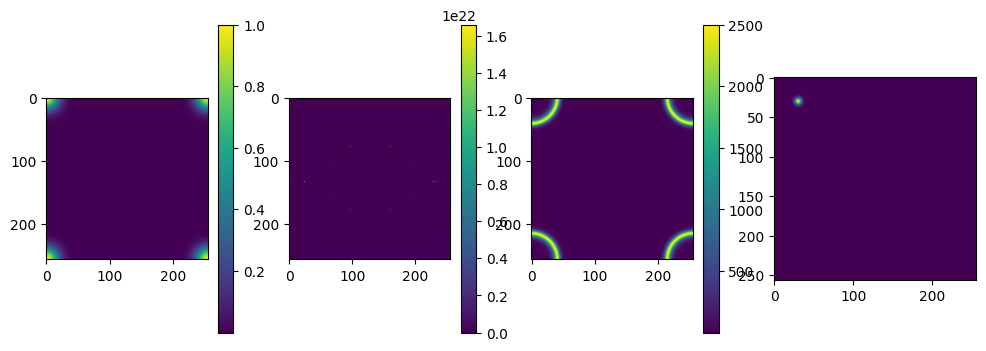

In [67]:
fig, ax = plt.subplots(1,4, figsize=(12,4))
fig.colorbar(ax[0].imshow((torch.abs(f_kernel) + eps).numpy() ** 1))
fig.colorbar(ax[1].imshow(fft_inverse.numpy() ** 2))
fig.colorbar(ax[2].imshow(fft_inverse_reg.numpy() ** 2 + 1))
ax[3].imshow(kernel_padded.numpy())
# plt.figure()
# plt.imshow(f_image.abs().numpy().transpose(1, 2, 0))

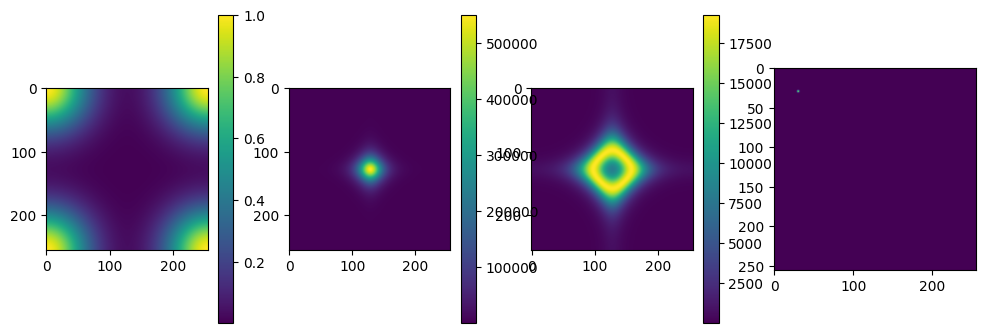

In [41]:
fig, ax = plt.subplots(1,4, figsize=(12,4))
fig.colorbar(ax[0].imshow((torch.abs(f_kernel) + eps).numpy() ** 1))
fig.colorbar(ax[1].imshow(fft_inverse.numpy() ** 2))
fig.colorbar(ax[2].imshow(fft_inverse_reg.numpy() ** 2))
ax[3].imshow(kernel_padded.numpy())
# plt.figure()
# plt.imshow(f_image.abs().numpy().transpose(1, 2, 0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4022418..2.4557319].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.061093032..1.105423].


Kernel size 32


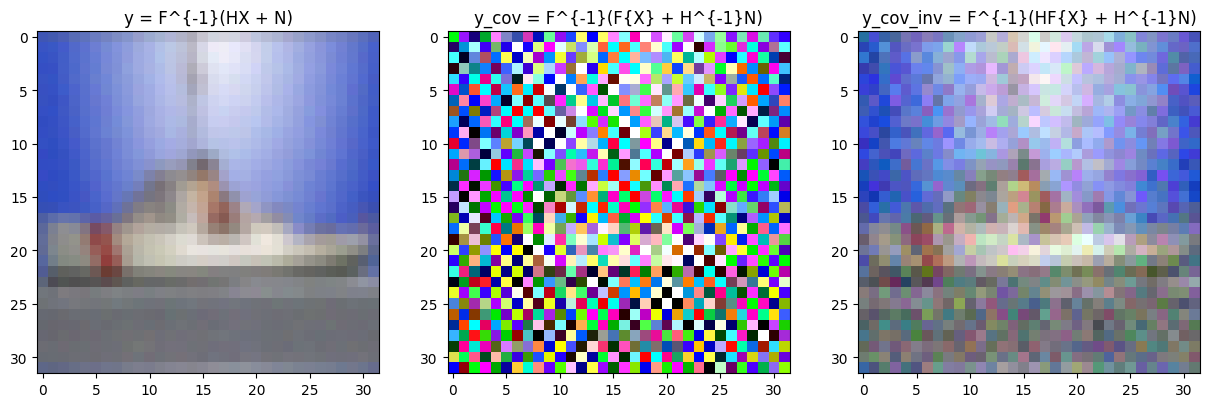

In [586]:
# kernel_padded = torch.zeros((img_dim, img_dim))
# kernel_padded[:kernel_size, :kernel_size] = kernel

# kernel_padded_shift = torch.fft.ifftshift(kernel_padded, dim=[-1, -2])

# # # FFTs
f_image = torch.fft.fft2(images[0][0], dim=[-1, -2])
# f_kernel = torch.fft.fft2(kernel_padded_shift, dim=[-1, -2])
# f_kernel_shift = torch.fft.fftshift(torch.fft.fft2(kernel_padded), dim=[-1, -2])
# f_kernel = downsampler_operator.get_padded_fourier_kernel(img_dim=32)
# print(f_kernel.shape)
eps = 0 #1e-1
sqrt_cov = f_kernel.abs() + eps
# sqrt`_cov = f_kernel.abs() + eps

# x_sr = downsampler_operator(images[0].double())

# y =  x_sr + 0 * torch.randn_like(x_sr)

y = torch.fft.ifft2(sqrt_cov * f_image + 0.01 * torch.fft.fft2(torch.randn_like(f_image))).real 
# y = y.real
y_cov =  images[0][0] + torch.fft.ifft2(0.1 * (sqrt_cov ** -1) * torch.fft.fft2(torch.randn_like(f_image))).real
# y_cov = downsampler_operator.reconstruct_image(y)
# y_cov_2 = downsampler_operator.H_transpose_fourier(y)
# y_cov_2 = downsampler_operator.apply_colored_noise(images[0][0].unsqueeze(0), noise_std=0.05)[0]
# print(images[0])
y_cov_inv = torch.fft.ifft2(sqrt_cov ** 1 * torch.fft.fft2(y_cov)).real
# y_white = torch.fft.ifft2(f_image + 0.001 * torch.fft.fft2(torch.randn_like(f_image))).real

fig, ax = plt.subplots(1,3, figsize=(15,15))
ax[0].imshow(y.numpy().transpose(1, 2, 0))
ax[0].set_title("y = F^{-1}(HX + N)")
ax[1].imshow(y_cov.numpy().transpose(1, 2, 0))
ax[1].set_title("y_cov = F^{-1}(F{X} + H^{-1}N)")
# ax[2].imshow(y_cov_2.numpy().transpose(1, 2, 0))
# ax[2].set_title("y_cov_2 = F^{-1}(F{X} + H^{-1}N)")
ax[2].imshow(y_cov_inv.numpy().transpose(1, 2, 0))
ax[2].set_title("y_cov_inv = F^{-1}(HF{X} + H^{-1}N)")
# ax[2].imshow(y_white.numpy().transpose(1, 2, 0))
# ax[2].set_title("y_white")/
# ax[4].imshow(images[0].numpy().transpose(1, 2, 0))
# ax[4].set_title("Original image")
print(f"Kernel size {kernel_size}")

In [651]:
class DownSampling(torch.nn.Module):
    """
    A PyTorch module that combines blurring and downsampling into a single
    convolutional operation.
    """
    def __init__(self, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = kernel_size

        # Create the Conv2d layer
        self.conv_layer = torch.nn.Conv2d(in_channels=3,
                         out_channels=3,
                         kernel_size=self.kernel_size,
                         stride=self.stride,
                         padding=0,
                         groups=3) # groups=in_channels makes it a depthwise convolution

        self.init_weights()

    def init_weights(self):
        avg_kernel_value = 1.0 / (self.kernel_size * self.kernel_size)
        self.k = torch.full((3, 1, self.kernel_size, self.kernel_size), avg_kernel_value)      
          # Set the weights and disable gradient updates
        self.conv_layer.weight = torch.nn.Parameter(self.k, requires_grad=False)
          
          # Set the bias to zero and disable gradient updates
        self.conv_layer.bias = torch.nn.Parameter(torch.zeros(3), requires_grad=False)

    def forward(self, input_tensor):
        # Apply the convolution to the input tensor
        output = self.conv_layer(input_tensor)
  
        return output

    
    def get_kernel(self):
        return self.k
    
    def get_fourier(self, img_dim):
        kernel_padded = torch.zeros((img_dim, img_dim))
        kernel_padded[:self.kernel_size, :self.kernel_size] = self.k[0,0,:,:]
        k_fourier = torch.fft.fft2(kernel_padded)
        return k_fourier

    def get_inverse_fourier(self, img_dim, epsilon = 0):
        # Get the FFT of the padded kernel
        f_kernel = self.get_fourier(img_dim)
        f_kernel = f_kernel + epsilon
        
        return f_kernel ** -1
    
    def get_inverse_reg_fourier(self, img_dim, epsilon = 1e-8):
        # Get the FFT of the padded kernel
        f_kernel = self.get_fourier(img_dim)

        # Get the magnitude squared
        f_kernel_mag_sq = torch.abs(f_kernel)**2

        # Add a small epsilon for numerical stability
        stabilized_denominator = f_kernel_mag_sq + epsilon

        # Compute the inverse filter
        # The inverse filter is the complex conjugate of the original filter
        # divided by the magnitude squared (plus epsilon)
        inverse_filter_fourier = torch.conj(f_kernel) / stabilized_denominator

        return inverse_filter_fourier



torch.Size([3, 1, 4, 4])


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

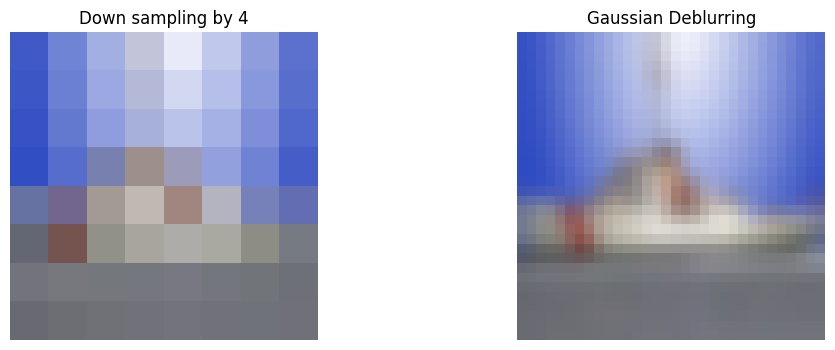

In [691]:
kernel_size = 4
sr_operator = DownSampling(kernel_size)
downsampled_tensor = sr_operator(images[0])
print(sr_operator.get_kernel().shape)

kernel_size = 7
blur_kernel = Blurkernel(blur_type='gaussian', kernel_size=kernel_size, std=1, device='cpu')
kernel = blur_kernel.get_kernel()
blur_tensor = blur_kernel(images[0])

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].imshow(downsampled_tensor[0].numpy().transpose(1, 2, 0))
ax[1].imshow(blur_tensor[0].detach().numpy().transpose(1, 2, 0))
ax[0].set_title('Down sampling by 4')
ax[1].set_title('Gaussian Deblurring')
ax[0].axis("off")
ax[1].axis("off")

Text(0.5, 1.0, 'Downsampling kernel (padded)')

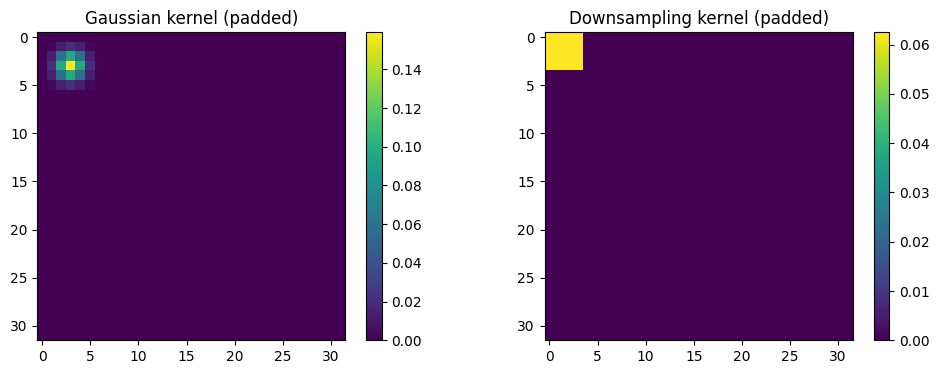

In [704]:
padded_kernel = torch.zeros((32, 32))
padded_kernel[:kernel_size, :kernel_size] = blur_kernel.get_kernel()

padded_kernel_sr = torch.zeros((32, 32))
padded_kernel_sr[:4, :4] = sr_operator.get_kernel()[0,0,:,:]

# Compute the 2D FFT of the padded kernel
fft_kernel = torch.fft.fft2(padded_kernel, dim=(-2, -1))

# Get the magnitude of the complex FFT output
fft_magnitude = torch.abs(sr_operator.get_fourier(32)) + 1
fft_magnitude_blur = torch.abs(blur_kernel.get_fourier(32)) + 1
fft_inverse_reg = blur_kernel.get_inverse_reg_fourier(32, eps).abs()
fft_inverse = sr_operator.get_inverse_reg_fourier(32, 1e-6).abs()
# Shift the zero-frequency component to the center
fft_shifted = torch.fft.fftshift(fft_magnitude)

fig, ax = plt.subplots(1,2, figsize=(12,4))
# fig.colorbar(ax[0].imshow(fft_magnitude.numpy() ** 2))
# fig.colorbar(ax[1].imshow(fft_inverse.numpy() ** 2 + 1))
# fig.colorbar(ax[2].imshow(fft_inverse_reg.numpy() ** 2))
fig.colorbar(ax[0].imshow(padded_kernel.numpy()))
fig.colorbar(ax[1].imshow(padded_kernel_sr.numpy()))
ax[0].set_title("Gaussian kernel (padded)")
ax[1].set_title("Downsampling kernel (padded)")
# ax[0].axis("off")
# ax[1].axis("off")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6912976..1.7587546].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6256448..1.6768056].


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

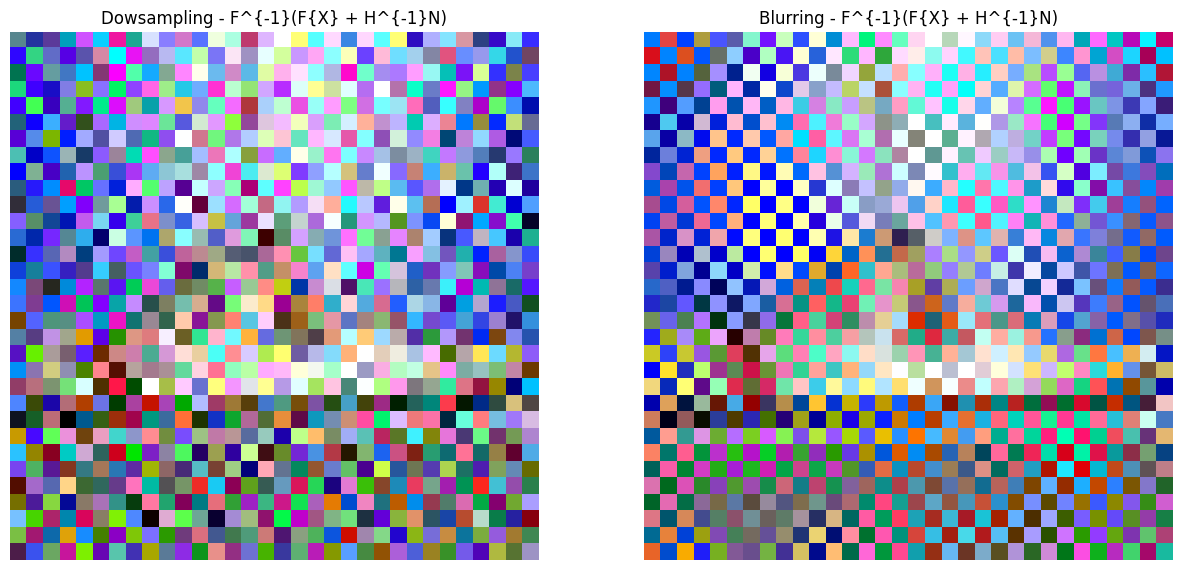

In [699]:
fig, ax = plt.subplots(1,2, figsize=(15,15))
ax[1].imshow(y_cov_blur.numpy().transpose(1, 2, 0))
ax[1].set_title("Blurring - F^{-1}(F{X} + H^{-1}N)")
ax[0].imshow(y_cov.numpy().transpose(1, 2, 0))
ax[0].set_title("Dowsampling - F^{-1}(F{X} + H^{-1}N)")
ax[0].axis("off")
ax[1].axis("off")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6256448..1.6768056].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6912976..1.7587546].


Kernel size 7
Kernel size 7


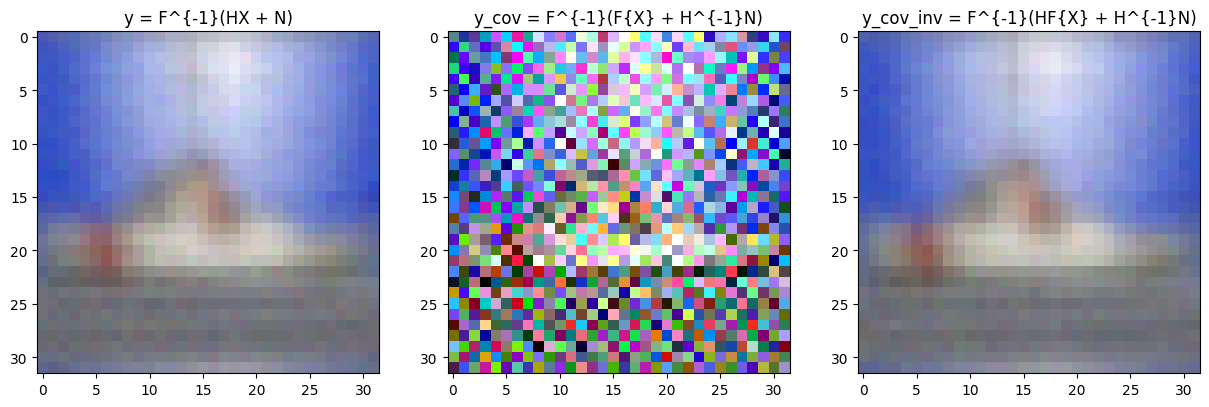

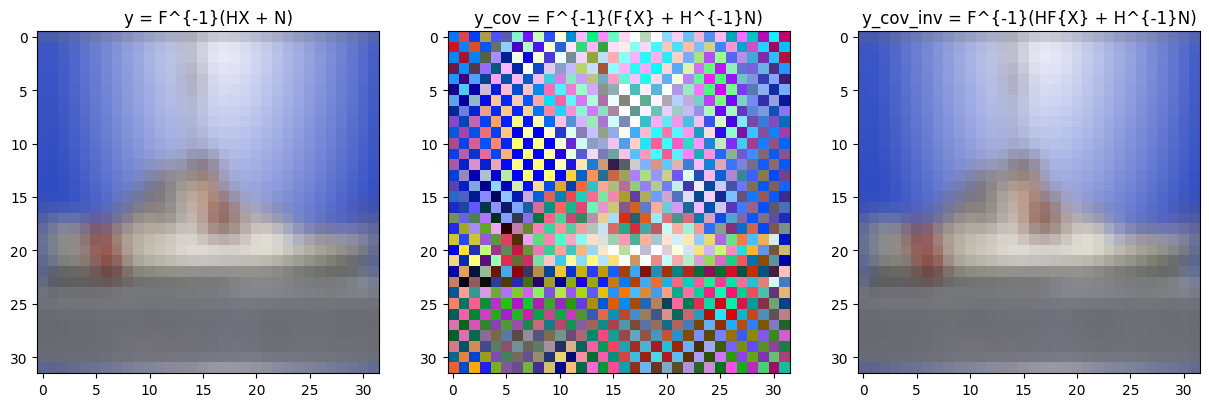

In [696]:
# # # FFTs
f_image = torch.fft.fft2(images[0][0], dim=[-1, -2])
f_kernel = sr_operator.get_fourier(32)
sqrt_cov = f_kernel.abs()
sqrt_cov_inverse = torch.sqrt(sr_operator.get_inverse_reg_fourier(32).abs()**2 + 1)
f_kernel_blur = blur_kernel.get_fourier(32)
sqrt_cov_blur = f_kernel_blur.abs()
sqrt_cov_blur_inverse = blur_kernel.get_inverse_reg_fourier(32).abs()
# sqrt`_cov = f_kernel.abs() + eps

# x_sr = downsampler_operator(images[0].double())

# y =  x_sr + 0 * torch.randn_like(x_sr)

y = torch.fft.ifft2(sqrt_cov * f_image + 2e-2 * torch.fft.fft2(torch.randn_like(f_image))).real 
y_cov =  images[0][0] + torch.fft.ifft2(2e-2 * (sqrt_cov_inverse) * torch.fft.fft2(torch.randn_like(f_image))).real
y_cov_inv = torch.fft.ifft2(sqrt_cov ** 1 * torch.fft.fft2(y_cov)).real

y_blur = torch.fft.ifft2(sqrt_cov_blur * f_image + 0.1e-2 * torch.fft.fft2(torch.randn_like(f_image))).real 
y_cov_blur =  images[0][0] + torch.fft.ifft2(0.1e-2 * (sqrt_cov_blur_inverse) * torch.fft.fft2(torch.randn_like(f_image))).real
y_cov_blur_inv = torch.fft.ifft2(sqrt_cov_blur ** 1 * torch.fft.fft2(y_cov_blur)).real


fig, ax = plt.subplots(1,3, figsize=(15,15))
ax[0].imshow(y.numpy().transpose(1, 2, 0))
ax[0].set_title("y = F^{-1}(HX + N)")
ax[1].imshow(y_cov.numpy().transpose(1, 2, 0))
ax[1].set_title("y_cov = F^{-1}(F{X} + H^{-1}N)")
ax[2].imshow(y_cov_inv.numpy().transpose(1, 2, 0))
ax[2].set_title("y_cov_inv = F^{-1}(HF{X} + H^{-1}N)")
print(f"Kernel size {kernel_size}")

fig, ax = plt.subplots(1,3, figsize=(15,15))
ax[0].imshow(y_blur.numpy().transpose(1, 2, 0))
ax[0].set_title("y = F^{-1}(HX + N)")
ax[1].imshow(y_cov_blur.numpy().transpose(1, 2, 0))
ax[1].set_title("y_cov = F^{-1}(F{X} + H^{-1}N)")
ax[2].imshow(y_cov_blur_inv.numpy().transpose(1, 2, 0))
ax[2].set_title("y_cov_inv = F^{-1}(HF{X} + H^{-1}N)")
print(f"Kernel size {kernel_size}")

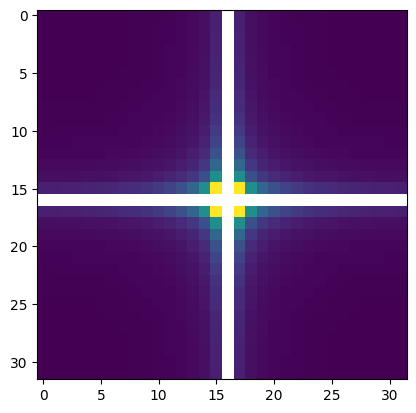

In [599]:
plt.imshow(sqrt_cov_inverse)

## Plot histogram of noise levels
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].hist(psnr_var, bins=50)
ax[0].set_xlabel('PSNR Variance')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Histogram of PSNR Variance')
ax[0].grid(True)

ax[1].hist(mse_var, bins=50)
ax[1].set_xlabel('MSE Variance')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Histogram of MSE Variance')
ax[1].grid(True)

In [7]:
args['noise_sampler']

'WhiteGaussianSampler()'

In [8]:
batch_test = 10
CHW = 3 * 32 * 32
sampler = 'ColoredGaussian'
# sampler = args['noise_sampler']

if sampler == args['noise_sampler']: #White sampler
    noisy_sampler: NoisySampler = eval(args['noise_sampler'])
    noise_level = noise_level_sampler.sample_noise_levels((images[0].shape[0], 1), 'cpu')
    samples = noisy_sampler.sample_noisy(images[0], noise_level, ())
else:
    shape = (images[0][0:batch_test].shape[0], CHW)
    noise_level = noise_level_sampler.sample_noise_levels((images[0].shape[0], 1), 'cpu')
    noisy_sampler = ColoredGaussianSampler(noise_level_sampler, shape = shape)
    # cov = noisy_sampler.sample_cov('cpu')
    samples = noisy_sampler.sample_noisy(images[0][0:batch_test])

In [ ]:
time_tracker: TimeTracker = TimeTracker()
time_tracker.switch("initialization")

min_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["min_noise_level"]) # This calls denoising error
max_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["max_noise_level"])
noise_level_sampler: NoiseLevelSampler = eval(args["noise_level_sampler"])(min=min_noise_level, max=max_noise_level)

shape = (images[0].shape[0], CHW)
noisy_sampler = ColoredGaussianSampler(noise_level_sampler, shape = shape)

In [32]:
for batch in noisy_loader(train_dataloader, noise_level_sampler, noisy_sampler, time_tracker):

    input = ColoredModelInput(noisy=batch.noisy, colored_noise_level=batch.noise_level)
    break

In [33]:
input.colored_noise_level

## Testing Wavelets

In [49]:
train_dataloader, test_dataloader, dataset_info = load_data(
    dataset=args["dataset"], spatial_size=args["spatial_size"], grayscale=args["grayscale"], horizontal_flip=args["horizontal_flip"], data_subset=eval(args["data_subset"]),
    train_batch_size=args["train_batch_size"], test_batch_size=args["test_batch_size"], num_workers=args["num_workers"], seed=1
)

images = next(iter(train_dataloader))  # load for testing things.
C, H, W = 3, 32, 32
shape = (images[0].shape[0], C * H* W)
device = 'cuda'

min_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["min_noise_level"]) # This calls denoising error
max_noise_level: NoiseLevel = NoiseLevel.from_unit(dataset_info=dataset_info, **args["max_noise_level"])
noise_level_sampler: NoiseLevelSampler = eval(args["noise_level_sampler"])(min=min_noise_level, max=max_noise_level)

covariance = spatial_corr_covariance(spatial_size=H, box_size=12, var_box=1, device=device, var_clean=1e-3)
noisy_sampler = MultipleColoredGaussianSamplerWithInput(noise_covariance=covariance)

In [134]:
def generate_2d_polynomial(
    resolution: int = 32,
    coefficients: dict = None,
    x_range: tuple = (0.0, 1.0),
    y_range: tuple = (0.0, 1.0)
) -> torch.Tensor:
    """
    Generates a 2D 3rd-order polynomial surface as a PyTorch tensor.

    The polynomial function is:
    P(x, y) = c00 + c10*x + c01*y + c20*x^2 + c11*x*y + c02*y^2 +
              c30*x^3 + c21*x^2*y + c12*x*y^2 + c03*y^3

    Args:
        resolution (int): The resolution of the 2D grid (e.g., 32 for 32x32).
        coefficients (dict, optional): A dictionary of coefficients for the polynomial terms.
                                      Keys should match the coefficient names (e.g., 'c00', 'c10').
                                      If a coefficient is not provided, it defaults to 0.0.
                                      Default coefficients create a simple diagonal gradient.
        x_range (tuple): A tuple (min_x, max_x) defining the range for the x-coordinates.
        y_range (tuple): A tuple (min_y, max_y) defining the range for the y-coordinates.

    Returns:
        torch.Tensor: A 2D PyTorch tensor of shape (resolution, resolution)
                      representing the polynomial surface.
    """
    # Default coefficients for a simple diagonal gradient if none are provided
    default_coefficients = {
        'c00': 0.0, 'c10': 1.0, 'c01': 1.0,
        'c20': 0.0, 'c11': 0.0, 'c02': 0.0,
        'c30': 0.0, 'c21': 0.0, 'c12': 0.0, 'c03': 0.0
    }

    # Update default coefficients with any user-provided coefficients
    if coefficients is None:
        coeffs = default_coefficients
    else:
        coeffs = {**default_coefficients, **coefficients}

    # Create a grid of x and y coordinates
    # torch.linspace creates evenly spaced numbers over a specified interval.
    x_coords = torch.linspace(x_range[0], x_range[1], resolution)
    y_coords = torch.linspace(y_range[0], y_range[1], resolution)

    # Create a 2D meshgrid from the 1D coordinate arrays
    # X and Y will be (resolution, resolution) tensors
    X, Y = torch.meshgrid(x_coords, y_coords, indexing='xy')

    # Calculate the polynomial values element-wise
    # Each term is multiplied by its corresponding coefficient
    P = (
        coeffs['c00'] +
        coeffs['c10'] * X +
        coeffs['c01'] * Y +
        coeffs['c20'] * X**2 +
        coeffs['c11'] * X * Y +
        coeffs['c02'] * Y**2 +
        coeffs['c30'] * X**3 +
        coeffs['c21'] * X**2 * Y +
        coeffs['c12'] * X * Y**2 +
        coeffs['c03'] * Y**3
    )

    return P


def generate_1d_polynomial(
    resolution: int = 32,
    coefficients: dict = None,
    x_range: tuple = (0.0, 1.0),
) -> torch.Tensor:
    """
    Generates a 2D 3rd-order polynomial surface as a PyTorch tensor.

    The polynomial function is:
    P(x, y) = c00 + c10*x + c01*y + c20*x^2 + c11*x*y + c02*y^2 +
              c30*x^3 + c21*x^2*y + c12*x*y^2 + c03*y^3

    Args:
        resolution (int): The resolution of the 2D grid (e.g., 32 for 32x32).
        coefficients (dict, optional): A dictionary of coefficients for the polynomial terms.
                                      Keys should match the coefficient names (e.g., 'c00', 'c10').
                                      If a coefficient is not provided, it defaults to 0.0.
                                      Default coefficients create a simple diagonal gradient.
        x_range (tuple): A tuple (min_x, max_x) defining the range for the x-coordinates.
        y_range (tuple): A tuple (min_y, max_y) defining the range for the y-coordinates.

    Returns:
        torch.Tensor: A 2D PyTorch tensor of shape (resolution, resolution)
                      representing the polynomial surface.
    """
    # Default coefficients for a simple diagonal gradient if none are provided
    default_coefficients = {
        'c0': 0.0, 'c1': 1.0, 'c2': 1.0, 'c3': 0.0
    }

    # Update default coefficients with any user-provided coefficients
    if coefficients is None:
        coeffs = default_coefficients
    else:
        coeffs = {**default_coefficients, **coefficients}

    # Create a grid of x and y coordinates
    # torch.linspace creates evenly spaced numbers over a specified interval.
    X = torch.linspace(x_range[0], x_range[1], resolution)

    # Calculate the polynomial values element-wise
    # Each term is multiplied by its corresponding coefficient
    P = (
        coeffs['c0'] +
        coeffs['c1'] * X +
        coeffs['c2'] * X**2 +
        coeffs['c3'] * X**3
    )

    return P

poly = generate_2d_polynomial(resolution=32)
# poly = generate_1d_polynomial(resolution=32)
# plt.plot(poly.numpy())


In [141]:
# Load image
original = pywt.data.camera()

# Wavelet transform of image, and plot approximation and details
titles = ['Approximation', ' Horizontal detail',
          'Vertical detail', 'Diagonal detail']
data = poly[None, None,:,:].repeat(5, 1, 1, 1) #covariance.get_matrix()

l = 1
for j in [1,3,5]:
    coeffs2 = ptwt.wavedec2(data, f'bior{l}.{j}', level=1, mode="zero")
    LL, (LH, HL, HH) = coeffs2[0], coeffs2[1]
    # fig = plt.figure(figsize=(12, 3))
    # fig.suptitle(f"Wavelet decomposition of level 1 using Bior1.{j}", fontsize=14)
    
    # # Subplots
    # for i, a in enumerate([LL, LH, HL, HH]):
    #     ax = fig.add_subplot(1, 5, i + 1)
    #     ax.imshow(a.cpu().numpy(), interpolation="nearest", cmap=plt.cm.gray)
    #     ax.set_title(titles[i], fontsize=10)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    
    # # Input subplot
    # ax = fig.add_subplot(1, 5, 5)
    # ax.imshow(data.cpu().numpy(), interpolation="nearest", cmap=plt.cm.gray)
    # ax.set_title("Input", fontsize=10)
    # ax.set_xticks([])
    # ax.set_yticks([])
    
    # # This line is key — adjusts layout to reduce whitespace
    # plt.tight_layout(rect=[0, 0, 1, 0.90])  # ↓ top margin from 0.95 to 0.90
    
    # plt.show()


# Wavelet transform of image, and plot approximation and details
# titles = ['Approximation', ' Horizontal detail',
#           'Vertical detail', 'Diagonal detail']
# data = poly #covariance.get_matrix()

# for j in [1,3,5]:
#     coeffs2 = ptwt.wavedec(data, f'db{j}', level=1, mode="zero")
#     LL, HH = coeffs2[0], coeffs2[1]
#     fig = plt.figure(figsize=(12, 3))
#     fig.suptitle(f"Wavelet decomposition of level 1 using db{j}", fontsize=14)
    
#     # Subplots
#     for i, a in enumerate([LL, HH]):
#         ax = fig.add_subplot(1, 3, i + 1)
#         ax.plot(a.cpu().numpy())
#         ax.set_title(titles[i], fontsize=10)
#         ax.set_xticks([])
#         ax.set_yticks([])
    
#     # Input subplot
#     ax = fig.add_subplot(1, 3, i+2)
#     ax.plot(data.cpu().numpy())
#     ax.set_title("Input", fontsize=10)
#     ax.set_xticks([])
#     ax.set_yticks([])
    
#     # This line is key — adjusts layout to reduce whitespace
#     plt.tight_layout(rect=[0, 0, 1, 0.90])  # ↓ top margin from 0.95 to 0.90
    
#     plt.show()


    # fig.show()

In [142]:
LL.shape, LH.shape

(torch.Size([5, 1, 20, 20]), torch.Size([5, 1, 20, 20]))

In [24]:
import pytorch_wavelets

def downsample(x, num_times, wavelet="db2", mode="periodization"):
    """ Downsample an (*, H, W) image `num_times` times using the given wavelet filter. """
    transform = OneLevelWaveletTransform(wavelet=wavelet, mode=mode)

    for _ in range(num_times):
        x = transform.decompose(x)[..., 0, :, :]  # (*, H/2^j, W/2^j)

    return x


class OneLevelWaveletTransform(torch.nn.Module):
    """ Performs one-level wavelet decomposition (self.decompose) or reconstruction (self.reconstruct).
    Uses pytorch_wavelets (supports GPU and autodiff) when possible, but falls back to pywt when pytorch_wavelets is
    unreliable (it has border effects on small image sizes, see test_wavelets).
    Wavelet coefficients at scale j are represented as (*, 4, L/2^j, L/2^j) tensors.
    The first channel corresponds to low frequencies x_j,
    and the following 3 channels correspond to high frequencies x_j_bar.
    """
    def __init__(self, wavelet="db2", mode="periodization"):
        super().__init__()
        self.mode = mode
        self.wavelet = wavelet
        self.ok_shapes = {}  # (spatial shape, decompose?) -> can use pytorch_wavelets over pywt
        self.decompose_module = pytorch_wavelets.DWTForward(wave=self.wavelet, mode=self.mode)
        self.reconstruct_module = pytorch_wavelets.DWTInverse(wave=self.wavelet, mode=self.mode)

    def decompose_numpy(self, x):
        """ One-level wavelet decomposition, (*, L, L) to (*, 4, L/2, L/2), using numpy (CPU, no autodiff). """
        x_np = x.cpu().numpy()
        low, high = pywt.dwt2(x_np, wavelet=self.wavelet, mode=self.mode)
        # low is a (*, L/2, L/2) array, high is a tuple of (*, L/2, L/2) arrays.
        y = np.stack((low,) + high, axis=-3)  # (*, 4, L/2, L/2)
        return torch.from_numpy(y).to(dtype=x.dtype, device=x.device)

    def decompose_pytorch(self, x):
        """ One-level wavelet decomposition, (*, L, L) to (*, 4, L/2, L/2), using pytorch (GPU, autodiff). """
        # pytorch_wavelets wants (B, 1, L, L) input.
        batch_shape = x.shape[:-2]
        low, high = self.decompose_module(x.reshape((-1, 1) + x.shape[-2:]))
        # low is (B, 1, L/2, L/2), high is a list whose single element is (B, 1, 3, L/2, L/2).
        y = torch.cat((low, high[0][:, 0]), dim=1)  # (B, 4, L/2, L/2)
        return y.reshape(batch_shape + y.shape[-3:])  # (*, 4, L/2, L/2)

    def decompose(self, x):
        """ One-level wavelet decomposition, (*, L, L) to (*, 4, L/2, L/2). Uses pytorch if possible. """
        if self.is_shape_ok(x, decompose=True):
            return self.decompose_pytorch(x)
        else:
            return self.decompose_numpy(x)

    def reconstruct_numpy(self, x):
        """ One-level wavelet reconstruction, (*, 4, L/2, L/2) to (*, L, L), using numpy (CPU, no autodiff). """
        x_np = x.cpu().numpy()
        channels = tuple(x_np[..., c, :, :] for c in range(4))
        y = pywt.idwt2((channels[0], channels[1:]), wavelet=self.wavelet, mode=self.mode)  # (*, L, L)
        return torch.from_numpy(y).to(dtype=x.dtype, device=x.device)

    def reconstruct_pytorch(self, x):
        """ One-level wavelet reconstruction, (*, 4, L/2, L/2) to (*, L, L), using pytorch (GPU, autodiff). """
        # pytorch_wavelets wants ((B, 1, L/2, L/2), [(B, 1, 3, L/2, L/2))] input.
        batch_shape = x.shape[:-3]
        x = x.reshape((-1,) + x.shape[-3:])  # (B, 4, L/2, L/2)
        y = self.reconstruct_module((x[:, :1], (x[:, None, 1:],)))  # (B, 1, L, L)
        return y.reshape(batch_shape + y.shape[-2:])  # (*, L/2, L/2)

    def reconstruct(self, x):
        """ One-level wavelet reconstruction, (*, 4, L/2, L/2) to (*, L, L). Uses pytorch if possible. """
        if self.is_shape_ok(x, decompose=False):
            return self.reconstruct_pytorch(x)
        else:
            return self.reconstruct_numpy(x)

    def is_shape_ok(self, x, decompose):
        """ Returns whether pytorch_wavelets can be safely used over numpy wavelets for the given spatial shape.
        @param x: pytorch tensor of shape (*, [4,] L, L)
        @param decompose: whether to test decomposition or reconstruction
        @return: whether pytorch_wavelets returns the same output as pywt
        """
        shape = x.shape[-2:]  # (L, L)
        if (shape, decompose) not in self.ok_shapes:
            x = torch.rand((() if decompose else (4,)) + shape, device=x.device)  # (L, L) or (4, L, L)
            numpy = self.decompose_numpy if decompose else self.reconstruct_numpy
            pytorch = self.decompose_pytorch if decompose else self.reconstruct_numpy
            ok = torch.allclose(numpy(x), pytorch(x), atol=1e-06)
            if not ok:
                print(f"Warning: fallback to numpy wavelet {'decomposition' if decompose else 'reconstruction'} for spatial shape {shape}")
            self.ok_shapes[shape, decompose] = ok
        return self.ok_shapes[shape, decompose]


class OneLevelWaveletTransform_ptwt(torch.nn.Module):
    """ Performs one-level wavelet decomposition (self.decompose) or reconstruction (self.reconstruct).
    Uses pytorch_wavelets (supports GPU and autodiff) when possible, but falls back to pywt when pytorch_wavelets is
    unreliable (it has border effects on small image sizes, see test_wavelets).
    Wavelet coefficients at scale j are represented as (*, 4, L/2^j, L/2^j) tensors.
    The first channel corresponds to low frequencies x_j,
    and the following 3 channels correspond to high frequencies x_j_bar.
    """
    def __init__(self, wavelet="db2", mode="periodic"):
        super().__init__()
        self.mode = mode
        self.wavelet = wavelet
        self.ok_shapes = {}  # (spatial shape, decompose?) -> can use pytorch_wavelets over pywt
        # self.decompose_module = pytorch_wavelets.DWTForward(wave=self.wavelet, mode=self.mode)
        # self.reconstruct_module = pytorch_wavelets.DWTInverse(wave=self.wavelet, mode=self.mode)

    def decompose_numpy(self, x):
        """ One-level wavelet decomposition, (*, L, L) to (*, 4, L/2, L/2), using numpy (CPU, no autodiff). """
        x_np = x.cpu().numpy()
        low, high = pywt.dwt2(x_np, wavelet=self.wavelet, mode=self.mode)
        # low is a (*, L/2, L/2) array, high is a tuple of (*, L/2, L/2) arrays.
        y = np.stack((low,) + high, axis=-3)  # (*, 4, L/2, L/2)
        return torch.from_numpy(y).to(dtype=x.dtype, device=x.device)

    def decompose_pytorch(self, x):
        """ One-level wavelet decomposition, (*, L, L) to (*, 4, L/2, L/2), using pytorch (GPU, autodiff). """
        # pytorch_wavelets wants (B, 1, L, L) input.
        batch_shape = x.shape[:-2]
        low, high = ptwt.wavedec2(x, wavelet = self.wavelet, level=1, mode=self.mode)
        # low is (B, 1, L/2, L/2), high is a list whose single element is (B, 1, 3, L/2, L/2).
        y = torch.stack((low,) + high, dim=-3)  # (B, 4, L/2, L/2)
        return y # (*, 4, L/2, L/2)

    def decompose(self, x):
        """ One-level wavelet decomposition, (*, L, L) to (*, 4, L/2, L/2). Uses pytorch if possible. """
        return self.decompose_pytorch(x)
 

    def reconstruct_numpy(self, x):
        """ One-level wavelet reconstruction, (*, 4, L/2, L/2) to (*, L, L), using numpy (CPU, no autodiff). """
        x_np = x.cpu().numpy()
        channels = tuple(x_np[..., c, :, :] for c in range(4))
        y = pywt.idwt2((channels[0], channels[1:]), wavelet=self.wavelet, mode=self.mode)  # (*, L, L)
        return torch.from_numpy(y).to(dtype=x.dtype, device=x.device)

    def reconstruct_pytorch(self, x):
        """ One-level wavelet reconstruction, (*, 4, L/2, L/2) to (*, L, L), using pytorch (GPU, autodiff). """
        # pytorch_wavelets wants ((B, 1, L/2, L/2), [(B, 1, 3, L/2, L/2))] input.
        channels = tuple(x[..., c, :, :] for c in range(4))
        # print(len(channels), channels[0].shape, channels[1:][0].shape)
        y = ptwt.waverec2((channels[0], channels[1:]), wavelet=self.wavelet)  # (B, 1, L, L)
        return y  # (*, L/2, L/2)

    def reconstruct(self, x):
        """ One-level wavelet reconstruction, (*, 4, L/2, L/2) to (*, L, L). Uses pytorch if possible. """
        return self.reconstruct_pytorch(x)
 

    def is_shape_ok(self, x, decompose):
        """ Returns whether pytorch_wavelets can be safely used over numpy wavelets for the given spatial shape.
        @param x: pytorch tensor of shape (*, [4,] L, L)
        @param decompose: whether to test decomposition or reconstruction
        @return: whether pytorch_wavelets returns the same output as pywt
        """
        shape = x.shape[-2:]  # (L, L)
        if (shape, decompose) not in self.ok_shapes:
            x = torch.rand((() if decompose else (4,)) + shape, device=x.device)  # (L, L) or (4, L, L)
            numpy = self.decompose_numpy if decompose else self.reconstruct_numpy
            pytorch = self.decompose_pytorch if decompose else self.reconstruct_numpy
            ok = torch.allclose(numpy(x), pytorch(x), atol=1e-06)
            if not ok:
                print(f"Warning: fallback to numpy wavelet {'decomposition' if decompose else 'reconstruction'} for spatial shape {shape}")
            self.ok_shapes[shape, decompose] = ok
        return self.ok_shapes[shape, decompose]
# Test functions.

def test_wavelets():
    """ Checks that decomposition/reconstruction are inverse of each other for several image sizes. """
    # NOTE: for some reason db4 wavelet does not provide accurate reconstruction for small sizes even with pywt.
    wavelets = OneLevelWaveletTransform()

    device = torch.device("cuda")
    dtype = torch.float32
    kwargs = dict(dtype=dtype, device=device)
    wavelets.to(**kwargs)

    batch_shape = (1, 1)
    n = lambda x: torch.norm(torch.flatten(x))
    rel_err = lambda true, other: (n(true - other) / n(true)).item()
    for L in [32]:
        for decompose in [True]:
            shape = batch_shape + (L, L)
            x = covariance.get_matrix()[None, None, :, :]
            x_rec = wavelets.reconstruct(wavelets.decompose(x)) if decompose else wavelets.decompose(wavelets.reconstruct(x))
            print(x.shape, x_rec.shape)
            print(f"{L=} {decompose=} {rel_err(x, x_rec)=}")
    return x_rec
# def test_wavelets_ptwt():
#     """ Checks that decomposition/reconstruction are inverse of each other for several image sizes. """
#     # NOTE: for some reason db4 wavelet does not provide accurate reconstruction for small sizes even with pywt.
#     wavelets = OneLevelWaveletTransform_ptwt()

#     device = torch.device("cuda")
#     dtype = torch.float32
#     kwargs = dict(dtype=dtype, device=device)
#     wavelets.to(**kwargs)

#     batch_shape = (2, 3)
#     n = lambda x: torch.norm(torch.flatten(x))
#     rel_err = lambda true, other: (n(true - other) / n(true)).item()
#     for L in [2, 4, 8, 16]:
#         for decompose in [True, False]:
#             shape = batch_shape + (() if decompose else (4,)) + (L, L)
#             x = torch.rand(shape, **kwargs)
#             x_rec = wavelets.reconstruct(wavelets.decompose(x)) if decompose else wavelets.decompose(wavelets.reconstruct(x))
#             print(x.shape, x_rec.shape)
            # print(f"{L=} {decompose=} {rel_err(x, x_rec)=}")

In [29]:
# wavelets = OneLevelWaveletTransform()

# x_wavelet_l1 = wavelets.decompose(covariance.get_matrix()[None, None, :, :].cpu())
# x_wavelet_l2 = wavelets.decompose(x_wavelet_l1[0,:,0,:,:].cpu())


wavelets = OneLevelWaveletTransform()

shape_x = 4
x = torch.randn(1,1,shape_x,shape_x)
covariance = power_law_covariance_from_shape(spatial_size = 32, alpha = 2.3, c = 0.1, device = 'cuda', noise_level = 1)

x_wavelet_prev = covariance.get_matrix()[None, None, None, :, :].cpu()
# covariance = spatial_corr_covariance(spatial_size=H, box_size=12, var_box=1, device=device, var_clean=1e-3)
while x_wavelet_prev.shape[-1] != x.shape[-1]:
    x_wavelet = wavelets.decompose(x_wavelet_prev[:,:,0,:,:])
    x_wavelet_prev = x_wavelet



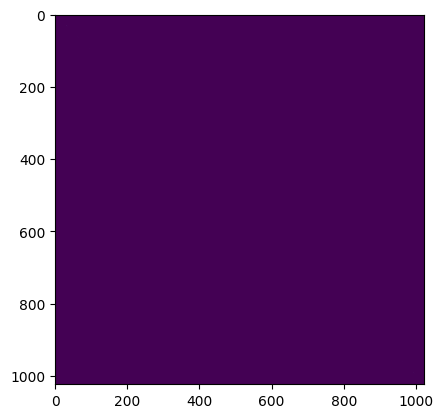

In [35]:
plt.imshow((torch.diag_embed(covariance.get_matrix()[:, :].view(-1))).cpu() * 10000)

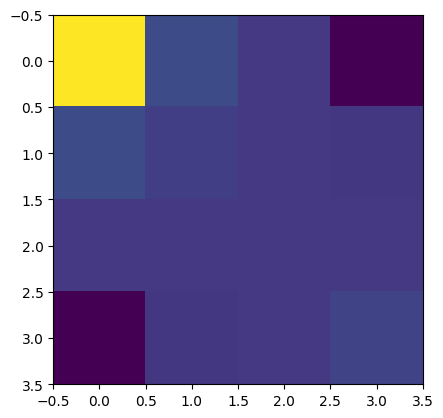

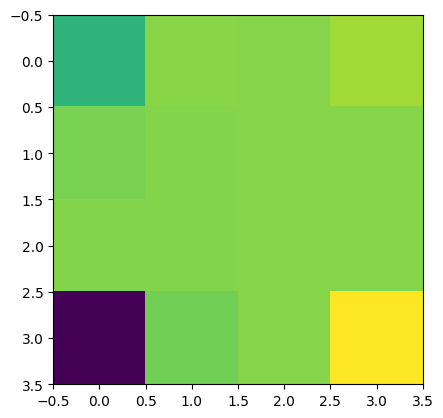

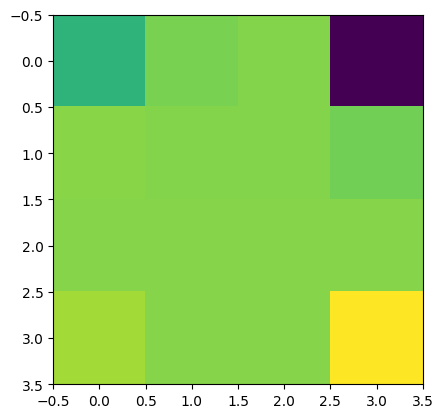

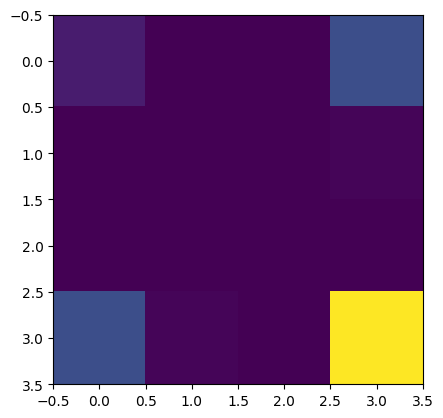

In [31]:
for j in range(4):
    plt.figure()
    plt.imshow(x_wavelet[0,0,j,:,:].cpu().numpy())

In [ ]:
class Downsampler(torch.nn.Module):
    """
    A PyTorch module that combines blurring and downsampling into a single
    convolutional operation.
    """
    def __init__(self, kernel, scale_factor):
        super().__init__()
        self.scale_factor = scale_factor
        kernel_size = kernel.shape[0]
        prepared_kernel = kernel.view(1, 1, kernel_size, kernel_size).repeat(3, 1, 1, 1)

        self.downsampler = torch.nn.Conv2d(
            in_channels=3,
            out_channels=3,
            kernel_size=kernel_size,
            stride=scale_factor,
            padding=(kernel_size - scale_factor) // 2, # Common padding strategy
            bias=False,
            groups=3
        )

        # 3. Load our custom blur kernel into the Conv2d layer's weights.
        self.downsampler.weight.data = prepared_kernel
        
        # 4. Make the layer non-trainable
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        """
        Takes a high-resolution image tensor (N, C, H, W) and returns a
        low-resolution version.
        """
        return self.downsampler(x)
    
    def get_kernel(self):
        return self.downsampler.weight.data[0, 0, :, :]
    
    def H_transpose_fourier(self, lr_image):
        """
        Applies the transpose operator H^T to a low-resolution image.
        This involves spatial upsampling (zero-insertion) followed by convolution.
        """
        n, c, h_lr, w_lr = lr_image.shape
        h_hr, w_hr = h_lr * self.scale_factor, w_lr * self.scale_factor
        
        # Get the HR fourier kernel (flipped for transpose, but Gaussian is symmetric)
        f_kernel_hr_conj = torch.conj(self.get_padded_fourier_kernel(h_hr))

        HT_channels = []
        for i in range(c):
            # Spatially upsample the LR image channel by inserting zeros
            upsampled_spatial = torch.zeros((h_hr, w_hr), device=lr_image.device)
            upsampled_spatial[::self.scale_factor, ::self.scale_factor] = lr_image[0, i]
            
            # Convolve in the Fourier domain
            f_upsampled = torch.fft.fft2(upsampled_spatial)
            f_HT_channel = f_upsampled * f_kernel_hr_conj
            
            HT_channel = torch.fft.ifft2(f_HT_channel).real
            HT_channels.append(HT_channel)
        
        return torch.stack(HT_channels, dim=0).unsqueeze(0)

    def get_HtH_fourier_operator(self, img_dim):
        """
        Computes the Fourier representation of the H^T * H operator.
        This is the aliased power spectrum of the HR blur kernel.
        """
        f_kernel_hr = self.get_padded_fourier_kernel(img_dim)
        power_spectrum_hr = torch.abs(f_kernel_hr)**2
        
        lr_dim = img_dim // self.scale_factor
        s = self.scale_factor
        f_HtH = torch.zeros_like(power_spectrum_hr)

        # Shift and sum to create the aliased power spectrum
        for i in range(s):
            for j in range(s):
                shifted_spectrum = torch.roll(power_spectrum_hr, shifts=(i * lr_dim, j * lr_dim), dims=(0, 1))
                f_HtH += shifted_spectrum
                
        return f_HtH / (s * s)
    
    # def get_HtH_fourier_operator(self, img_dim):
    #         """
    #         Computes the Fourier representation of H^T H.
    #         This is the aliased power spectrum of the blur kernel, which correctly
    #         models the blur and downsample/upsample round trip.
    #         """
    #         f_kernel_hr = self.get_padded_fourier_kernel(img_dim)
    #         power_spectrum_hr = torch.abs(f_kernel_hr)**2
            
    #         s = self.scale_factor
    #         lr_dim = img_dim // s
            
    #         # This is the robust method to compute the aliased spectrum
    #         # 1. Fold the HR spectrum to LR size by summing blocks
    #         f_HtH_lr = power_spectrum_hr.reshape(lr_dim, s, lr_dim, s).permute(0, 2, 1, 3).sum(dim=(-1, -2))
            
    #         # 2. Unfold the LR spectrum back to HR size by tiling
    #         f_HtH = f_HtH_lr.repeat_interleave(s, dim=0).repeat_interleave(s, dim=1)
            
    #         # 3. Apply energy normalization factor
    #         return f_HtH / (s * s)
        
    def apply_colored_noise(self, hr_image, noise_std):
        """
        Implements the full operation y = x + (H^T H)^-1 H^T n.
        """
        n, c, h_hr, w_hr = hr_image.shape
        h_lr, w_lr = h_hr // self.scale_factor, w_hr // self.scale_factor
        
        # 1. Create low-resolution Gaussian noise `n`
        lr_noise = torch.randn(n, c, h_lr, w_lr, device=hr_image.device)

        # 2. Compute H^T * n
        HTn = self.H_transpose_fourier(lr_noise)
        
        # 3. Get the Fourier operator for (H^T H) and its inverse
        f_HtH = self.get_HtH_fourier_operator(h_hr)
        # Add epsilon for numerical stability during division
        f_HtH_inv = 1.0 / (f_HtH)
        
        # 4. Apply (H^T H)^-1 to H^T n in the Fourier domain
        colored_noise_channels = []
        for i in range(c):
            f_HTn_channel = torch.fft.fft2(HTn[0, i])
            f_colored_noise_channel = f_HtH_inv * f_HTn_channel
            colored_noise_channel = torch.fft.ifft2(f_colored_noise_channel).real
            colored_noise_channels.append(colored_noise_channel)
        
        colored_noise = torch.stack(colored_noise_channels, dim=0).unsqueeze(0)
        
        # 5. Return x + colored_noise
        return hr_image + noise_std * colored_noise
    
    def reconstruct_image(self, lr_image):
        """
        Reconstructs an HR image from an LR image using the pseudo-inverse: (H^T H)^-1 H^T y.
        """
        n, c, h_lr, w_lr = lr_image.shape
        h_hr, w_hr = h_lr * self.scale_factor, w_lr * self.scale_factor

        # 1. Compute H^T * y (applies upsampling and blur)
        HTy = self.H_transpose_fourier(lr_image)
        
        # 2. Get the Fourier operator for (H^T H) and its inverse
        f_HtH = self.get_HtH_fourier_operator(h_hr)
        # Add epsilon for numerical stability
        f_HtH_inv = 1.0 / (f_HtH + 1e-8)
        
        # 3. Apply (H^T H)^-1 to H^T y in the Fourier domain (applies de-blur and de-aliasing)
        reconstructed_channels = []
        for i in range(c):
            f_HTy_channel = torch.fft.fft2(HTy[0, i])
            f_reconstructed_channel = f_HtH_inv * f_HTy_channel
            reconstructed_channel = torch.fft.ifft2(f_reconstructed_channel).real
            reconstructed_channels.append(reconstructed_channel)
        
        reconstructed_image = torch.stack(reconstructed_channels, dim=0).unsqueeze(0)
        
        return reconstructed_image

    def get_padded_fourier_kernel(self, img_dim):
        """Pads, shifts, and computes the HR FFT of the kernel."""
        kernel = self.get_kernel()
        kernel_size = kernel.shape[0]
        
        # 1. Create a zero tensor the size of the HR image
        kernel_padded = torch.zeros((img_dim, img_dim))

        # 2. Place the small kernel at the top-left corner
        kernel_padded[:kernel_size, :kernel_size] = kernel

        # 3. Center the kernel by circularly shifting it
        # This moves the kernel's center pixel to the (0, 0) position,
        # which is required for correct convolution via FFT to avoid phase errors.
        pad = kernel_size // 2
        kernel_shifted = torch.roll(kernel_padded, shifts=(-pad, -pad), dims=(0, 1))
        
        f_kernel = torch.fft.fft2(kernel_shifted)
        return f_kernel